<a href="https://colab.research.google.com/github/RughmaMalik/developershub_tasks/blob/main/term_deposit_subscription.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Term Deposit Subscription Prediction**

**Objective:**
Predict whether a bank customer will subscribe to a term deposit
as a result of a marketing campaign using machine learning classification models.

**IMPORT LIBRARIES**

In [1]:
!pip install lime

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, roc_curve, roc_auc_score, auc)
import lime
from lime import lime_tabular
import warnings

warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


**LOAD AND EXPLORE DATASET**

In [3]:
# Load the dataset
df = pd.read_csv('bank-additional-full.csv', sep=';')

print(f"\nDataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")


Dataset loaded successfully!
Shape: 41188 rows × 21 columns


In [4]:
# Display first few rows
print(df.head())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

In [5]:
# Dataset information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
# Statistical summary
print(df.describe())

               age      duration      campaign         pdays      previous  \
count  41188.00000  41188.000000  41188.000000  41188.000000  41188.000000   
mean      40.02406    258.285010      2.567593    962.475454      0.172963   
std       10.42125    259.279249      2.770014    186.910907      0.494901   
min       17.00000      0.000000      1.000000      0.000000      0.000000   
25%       32.00000    102.000000      1.000000    999.000000      0.000000   
50%       38.00000    180.000000      2.000000    999.000000      0.000000   
75%       47.00000    319.000000      3.000000    999.000000      0.000000   
max       98.00000   4918.000000     56.000000    999.000000      7.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx     euribor3m   nr.employed  
count  41188.000000    41188.000000   41188.000000  41188.000000  41188.000000  
mean       0.081886       93.575664     -40.502600      3.621291   5167.035911  
std        1.570960        0.578840       4.628198    

In [7]:
# Check for missing values
print(df.isnull().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


**DATA CLEANING AND PREPROCESSING**

In [8]:
# Check target variable distribution
print("\nTarget Distribution (%):")
print(df['y'].value_counts(normalize=True) * 100)

# Check for 'unknown' values
print("\n'Unknown' values in categorical features:")
for col in df.select_dtypes(include='object').columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} ({unknown_count/len(df)*100:.2f}%)")

# Separate features and target
X = df.drop('y', axis=1)
y = df['y'].map({'yes': 1, 'no': 0})
print(f"Target distribution: Class 0 (No): {(y==0).sum()}, Class 1 (Yes): {(y==1).sum()}")

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nCategorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")


Target Distribution (%):
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

'Unknown' values in categorical features:
job: 330 (0.80%)
marital: 80 (0.19%)
education: 1731 (4.20%)
default: 8597 (20.87%)
housing: 990 (2.40%)
loan: 990 (2.40%)
Target distribution: Class 0 (No): 36548, Class 1 (Yes): 4640

Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical features (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


**EXPLORATORY DATA ANALYSIS (EDA)**

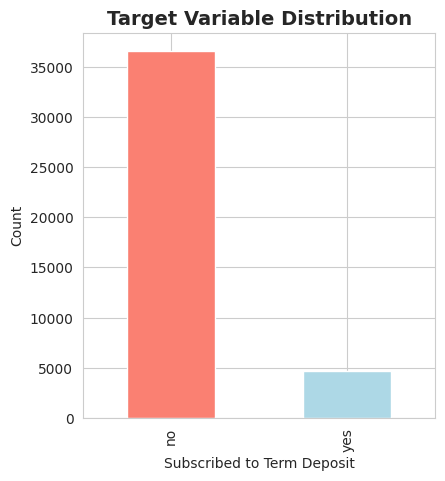

In [9]:
# 1. Target Distribution
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
df['y'].value_counts().plot(kind='bar', color=['salmon', 'lightblue'])
plt.title('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Count')
plt.show()

Text(0, 0.5, 'Frequency')

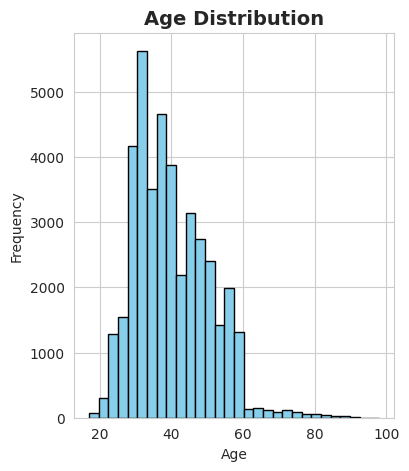

In [10]:
# 2. Age Distribution
plt.figure(figsize=(14, 5))
plt.subplot(1, 3, 1)
plt.hist(df['age'], bins=30, color='skyblue', edgecolor='black')
plt.title('Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')

<Figure size 1400x600 with 0 Axes>

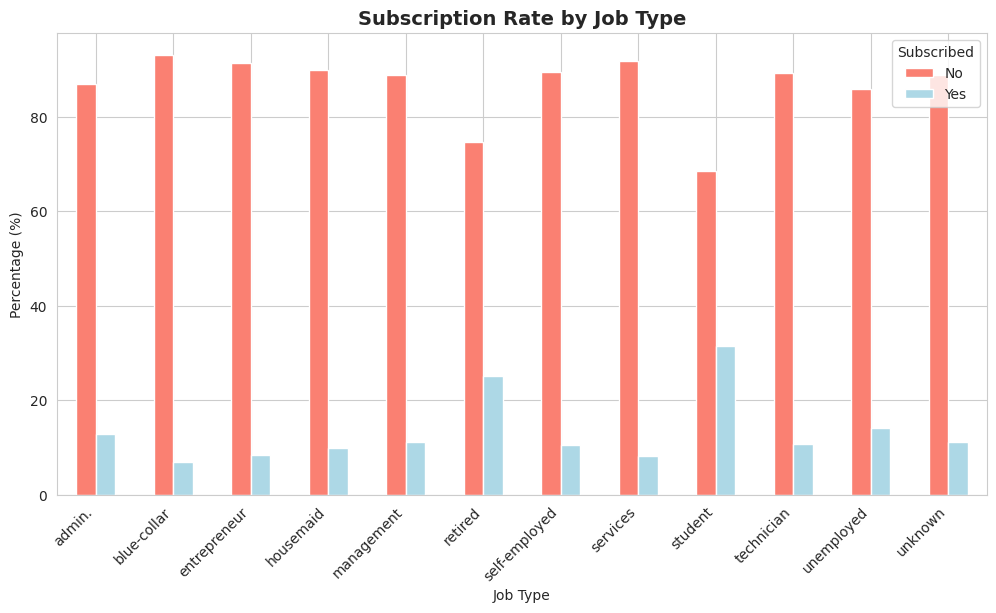

In [11]:
# 3. Job Analysis
plt.figure(figsize=(14, 6))
job_target = pd.crosstab(df['job'], df['y'], normalize='index') * 100
job_target.plot(kind='bar', stacked=False, color=['salmon', 'lightblue'])
plt.title('Subscription Rate by Job Type', fontsize=14, fontweight='bold')
plt.xlabel('Job Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(['No', 'Yes'], title='Subscribed')
plt.show()

<Figure size 1400x600 with 0 Axes>

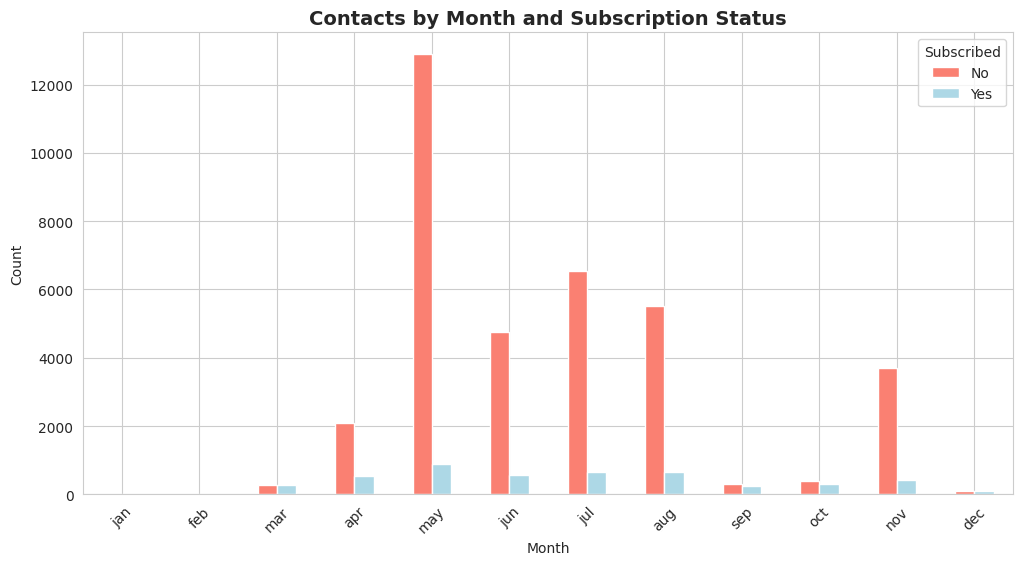

In [12]:
# 4. Month Analysis
plt.figure(figsize=(14, 6))
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_target = pd.crosstab(df['month'], df['y'])
month_target = month_target.reindex(month_order)
month_target.plot(kind='bar', color=['salmon', 'lightblue'])
plt.title('Contacts by Month and Subscription Status', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(['No', 'Yes'], title='Subscribed')
plt.show()


**FEATURE ENCODING**

In [13]:
# Create a copy for encoding
X_encoded = X.copy()

# Label encoding for categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le

**TRAIN-TEST SPLIT**

In [14]:
# Split data (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**MODEL BUILDING AND TRAINING**

In [15]:
# 1. Logistic Regression
print("Training Logistic Regression Model...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
print("Logistic Regression trained successfully")

Training Logistic Regression Model...
Logistic Regression trained successfully


In [16]:
# 2. Random Forest
print("Training Random Forest Model...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
print("Random Forest trained successfully")

Training Random Forest Model...
Random Forest trained successfully


**MODEL EVALUATION**

In [17]:
# Function to evaluate model
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):

    print(f"{model_name} EVALUATION")

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Training accuracy
    train_acc = (y_train_pred == y_train).mean()
    print(f"\nTraining Accuracy: {train_acc:.4f}")

    # Test accuracy
    test_acc = (y_test_pred == y_test).mean()
    print(f"Test Accuracy: {test_acc:.4f}")

    # F1 Score
    f1 = f1_score(y_test, y_test_pred)
    print(f"F1-Score: {f1:.4f}")

    # ROC-AUC Score
    roc_auc = roc_auc_score(y_test, y_test_proba)
    print(f"ROC-AUC Score: {roc_auc:.4f}")

    # Classification Report
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_test_pred,
                                target_names=['No', 'Yes']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)

    return y_test_pred, y_test_proba, cm, f1, roc_auc

In [18]:
# Evaluate Logistic Regression
lr_pred, lr_proba, lr_cm, lr_f1, lr_auc = evaluate_model(
    lr_model, X_train_scaled, X_test_scaled, y_train, y_test,
    "LOGISTIC REGRESSION"
)

LOGISTIC REGRESSION EVALUATION

Training Accuracy: 0.9095
Test Accuracy: 0.9139
F1-Score: 0.5193
ROC-AUC Score: 0.9370

Classification Report:
              precision    recall  f1-score   support

          No       0.93      0.98      0.95      7310
         Yes       0.70      0.41      0.52       928

    accuracy                           0.91      8238
   macro avg       0.81      0.70      0.74      8238
weighted avg       0.90      0.91      0.90      8238



In [19]:
# Evaluate Random Forest
rf_pred, rf_proba, rf_cm, rf_f1, rf_auc = evaluate_model(
    rf_model, X_train_scaled, X_test_scaled, y_train, y_test,
    "RANDOM FOREST"
)

RANDOM FOREST EVALUATION

Training Accuracy: 1.0000
Test Accuracy: 0.9205
F1-Score: 0.6023
ROC-AUC Score: 0.9491

Classification Report:
              precision    recall  f1-score   support

          No       0.94      0.97      0.96      7310
         Yes       0.69      0.53      0.60       928

    accuracy                           0.92      8238
   macro avg       0.82      0.75      0.78      8238
weighted avg       0.91      0.92      0.92      8238



**CONFUSION MATRIX VISUALIZATION**

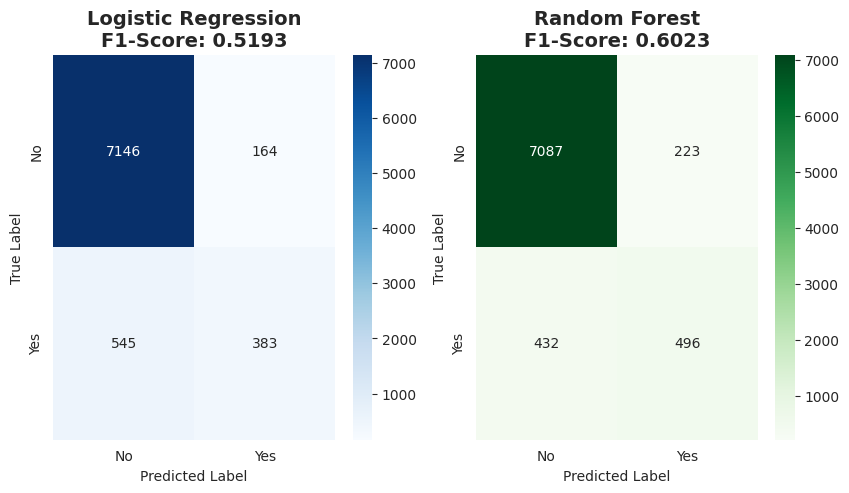

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Logistic Regression Confusion Matrix
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[0].set_title(f'Logistic Regression\nF1-Score: {lr_f1:.4f}',
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Random Forest Confusion Matrix
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[1].set_title(f'Random Forest\nF1-Score: {rf_f1:.4f}',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
plt.show()

**ROC CURVE VISUALIZATION**

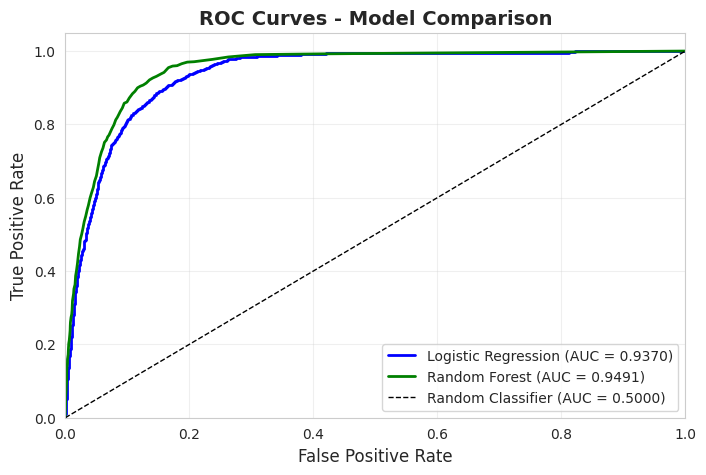

In [21]:
# Calculate ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)

# Plot ROC curves
plt.figure(figsize=(8, 5))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.4f})',
         linewidth=2, color='blue')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.4f})',
         linewidth=2, color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)',
         linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

**MODEL INTERPRETABILITY WITH LIME**

In [22]:
# Create LIME explainer
explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X_encoded.columns.tolist(),
    class_names=['No', 'Yes'],
    mode='classification'
)

# Select 5 diverse instances for explanation
# Get indices for different prediction scenarios
correctly_predicted_yes = np.where((y_test == 1) & (rf_pred == 1))[0]
correctly_predicted_no = np.where((y_test == 0) & (rf_pred == 0))[0]
false_positive = np.where((y_test == 0) & (rf_pred == 1))[0]
false_negative = np.where((y_test == 1) & (rf_pred == 0))[0]

# Select instances
instances_to_explain = [
    correctly_predicted_yes[0] if len(correctly_predicted_yes) > 0 else 0,
    correctly_predicted_no[0] if len(correctly_predicted_no) > 0 else 1,
    false_positive[0] if len(false_positive) > 0 else 2,
    false_negative[0] if len(false_negative) > 0 else 3,
    np.random.choice(len(X_test_scaled))
]

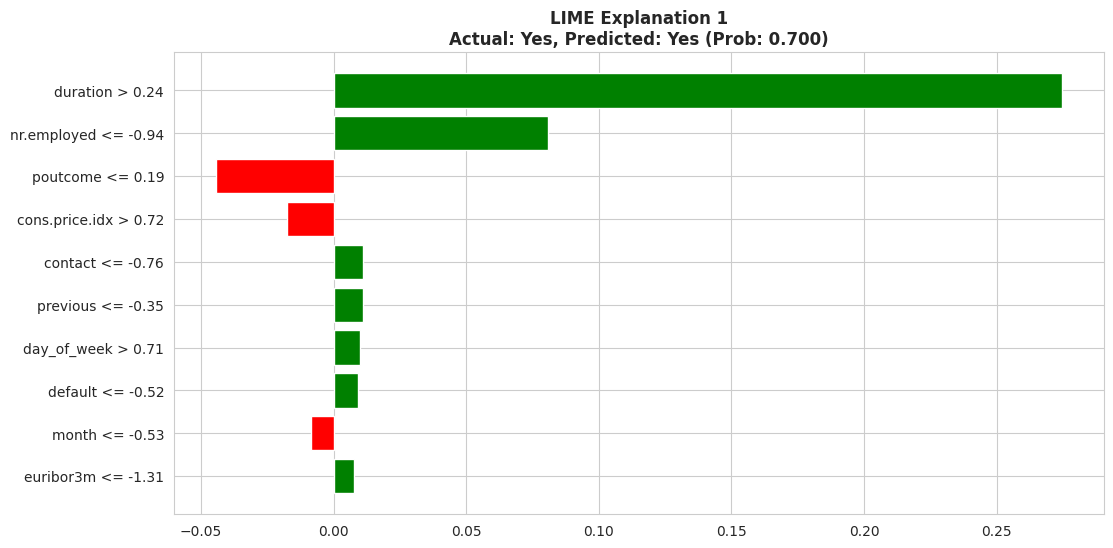

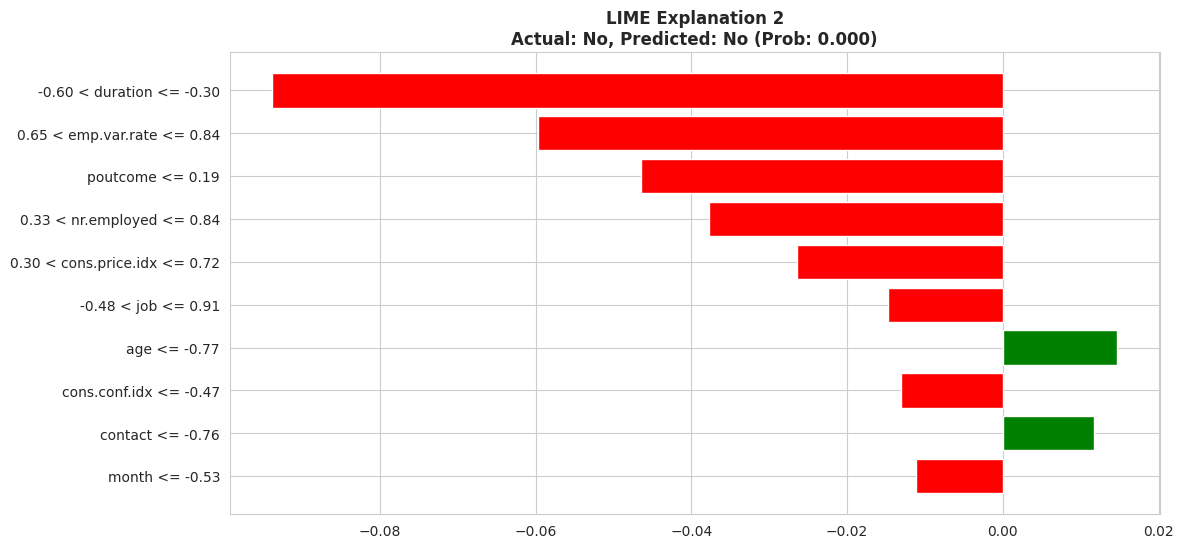

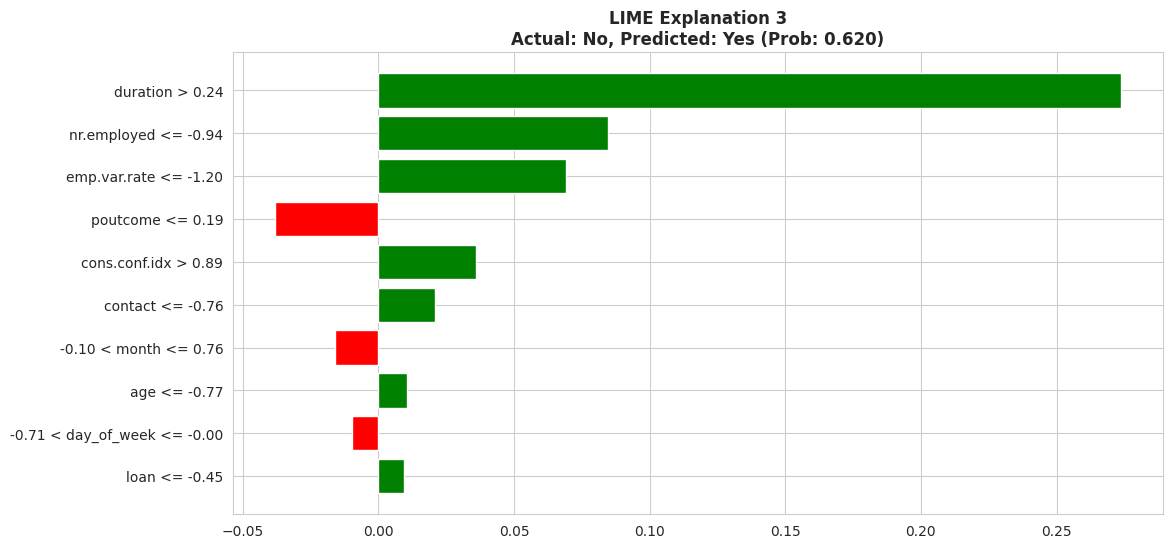

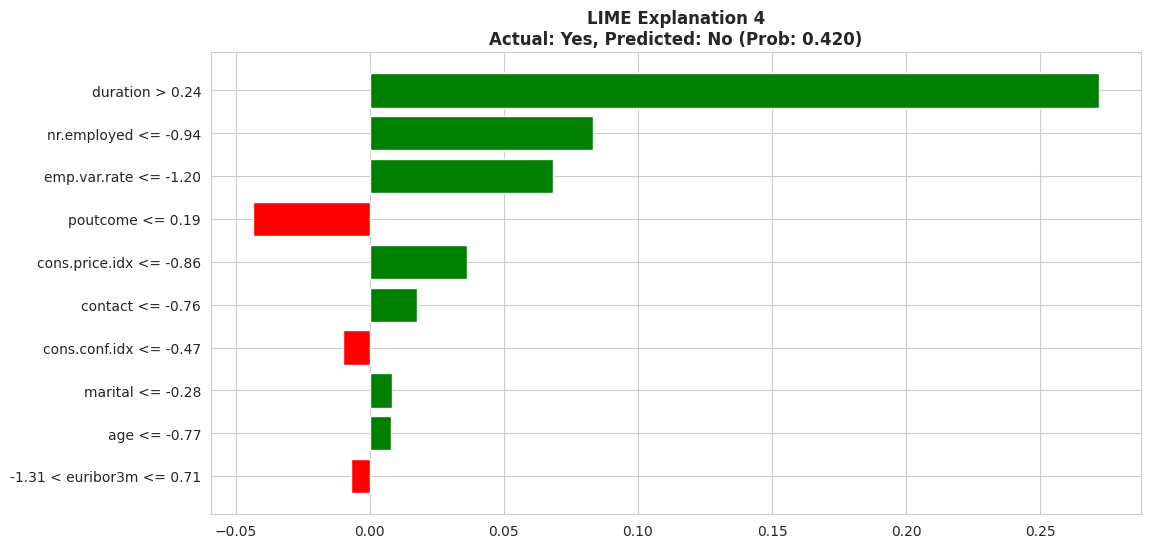

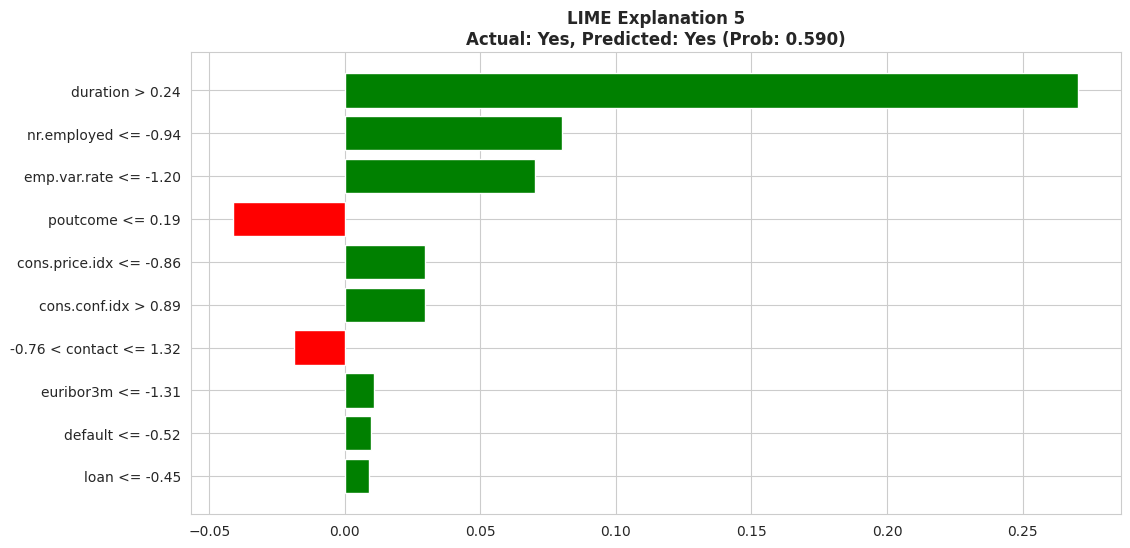

In [23]:
# Explain each instance
for idx, instance_idx in enumerate(instances_to_explain, 1):

    # Get instance
    instance = X_test_scaled[instance_idx]

    # Actual and predicted values
    actual = y_test.iloc[instance_idx]
    predicted = rf_pred[instance_idx]
    probability = rf_proba[instance_idx]

    # Generate explanation
    exp = explainer.explain_instance(
        instance,
        rf_model.predict_proba,
        num_features=10
    )

    # Plot explanation
    fig = exp.as_pyplot_figure()
    plt.title(f'LIME Explanation {idx}\n' +
              f'Actual: {"Yes" if actual == 1 else "No"}, ' +
              f'Predicted: {"Yes" if predicted == 1 else "No"} ' +
              f'(Prob: {probability:.3f})',
              fontsize=12, fontweight='bold')
    plt.show()

**CONCLUSION AND INSIGHTS**

**Insights:**
*   Random Forest performed better than Logistic Regression.
*   Call duration, contact type, and campaign history were strong predictors.
*   LIME explanations showed why individual customers subscribed or not, increasing trust in the model.

**Conclusion:**

This system successfully predicts customer subscription behavior and provides transparent explanations using LIME, making it suitable for real-world banking decision support systems.